# Sales Prediction Using Python

**Track:** Python / Data Science &nbsp;|&nbsp; **Task 5: Sales Prediction Using Python**

**Objective:** Build a regression model that predicts product sales based on advertising
spend across different media channels (TV, Radio, Newspaper).

**Dataset:** The classic [Advertising dataset](https://www.statlearning.com/) from
*An Introduction to Statistical Learning* — 200 markets, each with an advertising budget
(in thousands of dollars) for TV, Radio, and Newspaper, and the resulting product sales
(in thousands of units).

**Pipeline:** Load & inspect -> EDA (pairplot, scatter plots, correlation) -> train/test
split -> baseline Linear Regression -> a second model (Random Forest) -> evaluate (MAE,
RMSE, R²) -> residual analysis -> interpret which channel drives sales the most.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)


## 2. Load the data and check for issues

In [2]:
df = pd.read_csv("advertising.csv", index_col=0)

print(f"Shape: {df.shape}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print()
print(df.isna().sum())
print()
df.describe()


Shape: (200, 4)
Duplicate rows: 0

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64



,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


**Observation:** no missing values, no duplicates — this dataset is already clean, so we can move straight to exploration.

## 3. Exploratory Data Analysis

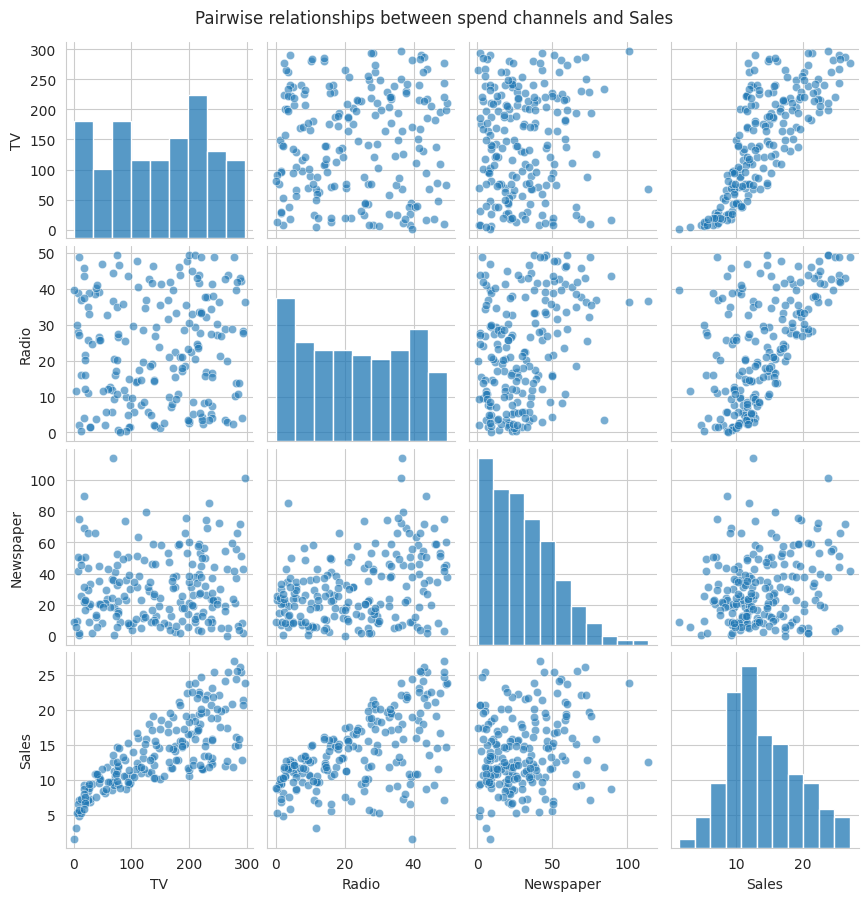

In [3]:
sns.pairplot(df, height=2.2, plot_kws={"alpha": 0.6})
plt.suptitle("Pairwise relationships between spend channels and Sales", y=1.02)
plt.show()


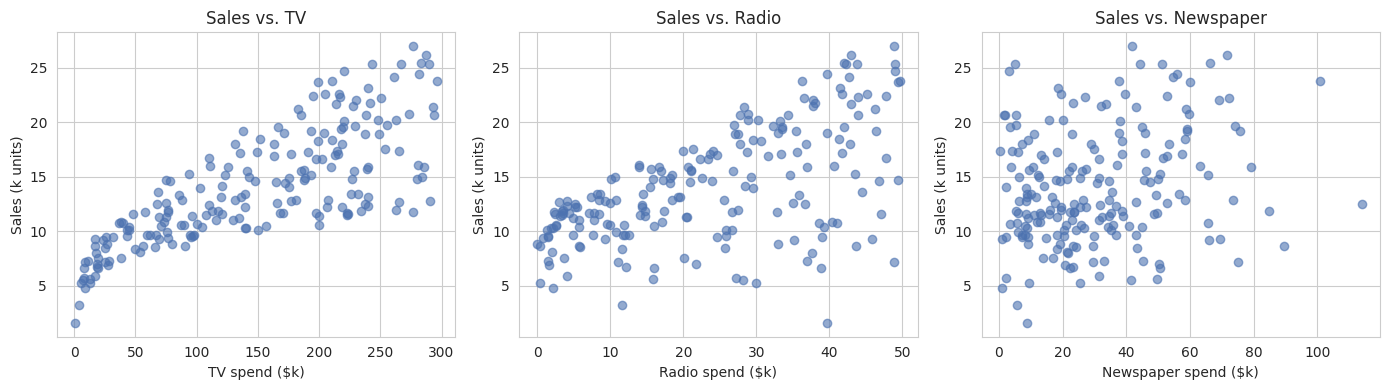

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ["TV", "Radio", "Newspaper"]):
    ax.scatter(df[col], df["Sales"], alpha=0.6, color="#4C72B0")
    ax.set_xlabel(f"{col} spend ($k)")
    ax.set_ylabel("Sales (k units)")
    ax.set_title(f"Sales vs. {col}")

plt.tight_layout()
plt.show()


**Observation:** `TV` spend shows the clearest, strongest linear relationship with `Sales`. `Radio` shows a moderate positive relationship. `Newspaper` shows the weakest, noisiest relationship of the three — a first hint (confirmed numerically below) that newspaper advertising isn't pulling much weight in this dataset.

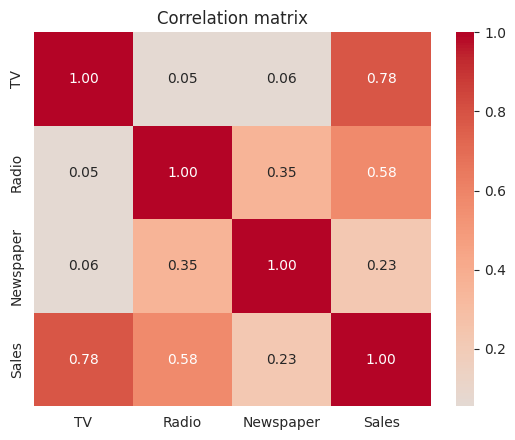

In [5]:
plt.figure(figsize=(5.5, 4.5))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()


**Observation:** `TV` correlates with `Sales` at r ≈ 0.78 — by far the strongest of the three channels. `Radio` is a distant second (r ≈ 0.58), and `Newspaper` is weak (r ≈ 0.23). Also worth noting: `Radio` and `Newspaper` spend are mildly correlated with each other (r ≈ 0.35), which is common in real ad budgets — campaigns often spread spend across print and radio together.

## 4. Train/test split

In [6]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")


Train size: 160  |  Test size: 40


## 5. Train models

1. **Linear Regression** — the baseline, per the task requirements. Its coefficients
   directly tell us the expected sales lift per extra dollar spent on each channel.
2. **Random Forest Regressor** — a second model to check whether there's meaningful
   non-linearity or channel interaction the linear model is missing.

In [7]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

rf_model = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Both models trained.")
print()
print("Linear Regression coefficients:")
for feature, coef in zip(X.columns, lr_model.coef_):
    print(f"  {feature:10s}: {coef:.4f}")
print(f"  Intercept : {lr_model.intercept_:.4f}")


Both models trained.

Linear Regression coefficients:
  TV        : 0.0447
  Radio     : 0.1892
  Newspaper : 0.0028
  Intercept : 2.9791


## 6. Evaluate

In [8]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"MAE  : {mae:.3f} (k units)")
    print(f"RMSE : {rmse:.3f} (k units)")
    print(f"R^2  : {r2:.4f}")
    print()
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []
results.append(evaluate("Linear Regression", y_test, lr_preds))
results.append(evaluate("Random Forest Regressor", y_test, rf_preds))

results_df = pd.DataFrame(results).set_index("model").round(4)
results_df


--- Linear Regression ---
MAE  : 1.461 (k units)
RMSE : 1.782 (k units)
R^2  : 0.8994

--- Random Forest Regressor ---
MAE  : 0.643 (k units)
RMSE : 0.781 (k units)
R^2  : 0.9807



,MAE,RMSE,R2
model,,,
Linear Regression,1.4608,1.7816,0.8994
Random Forest Regressor,0.6429,0.7808,0.9807


## 7. Residual plot (best model)

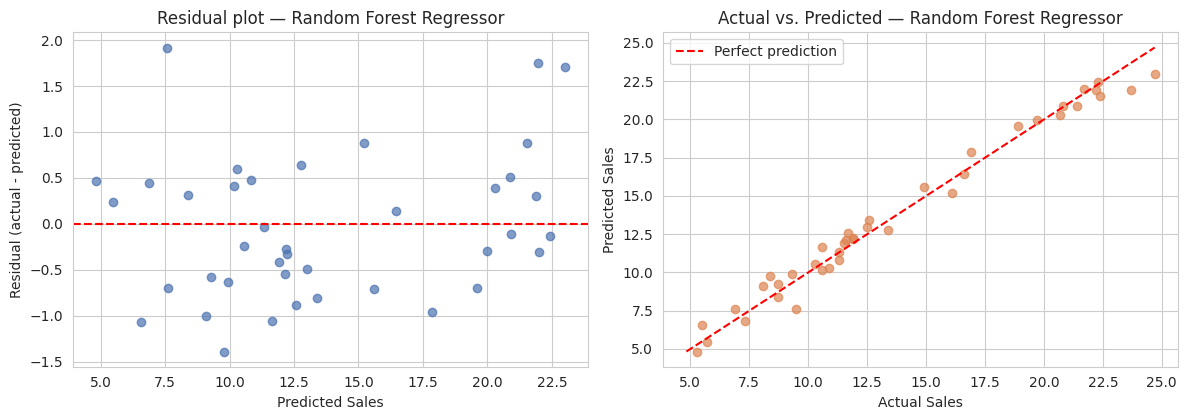

Best model by R^2 on this test set: Random Forest Regressor


In [9]:
best_name, best_preds = (
    ("Random Forest Regressor", rf_preds)
    if results_df.loc["Random Forest Regressor", "R2"] > results_df.loc["Linear Regression", "R2"]
    else ("Linear Regression", lr_preds)
)
residuals = y_test.values - best_preds

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))

axes[0].scatter(best_preds, residuals, alpha=0.7, color="#4C72B0")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Predicted Sales")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title(f"Residual plot — {best_name}")

axes[1].scatter(y_test, best_preds, alpha=0.7, color="#DD8452")
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
axes[1].plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
axes[1].set_xlabel("Actual Sales")
axes[1].set_ylabel("Predicted Sales")
axes[1].set_title(f"Actual vs. Predicted — {best_name}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Best model by R^2 on this test set: {best_name}")


**Observation:** residuals scattered evenly above and below the zero line with no funnel or curved pattern would indicate the model's errors are random noise rather than a systematic blind spot (e.g. consistently under-predicting at high spend levels). Check the plot above for that pattern before trusting the model's predictions at the edges of the spend range.

## 8. Which advertising channel has the highest impact on sales?

Linear Regression coefficients (expected sales lift per $1k extra spend):
Radio        0.189195
TV           0.044730
Newspaper    0.002761
dtype: float64

Random Forest feature importances:
TV           0.626801
Radio        0.361693
Newspaper    0.011506
dtype: float64


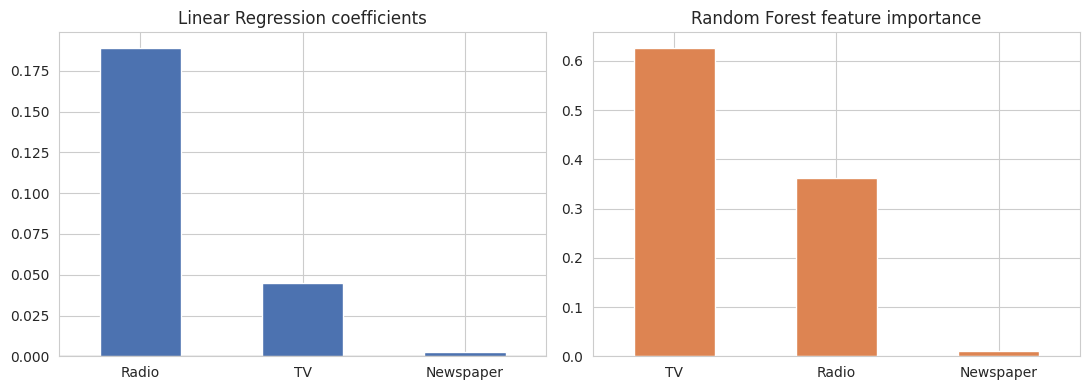

In [10]:
print("Linear Regression coefficients (expected sales lift per $1k extra spend):")
coef_series = pd.Series(lr_model.coef_, index=X.columns).sort_values(ascending=False)
print(coef_series)
print()

print("Random Forest feature importances:")
importance_series = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance_series)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
coef_series.plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Linear Regression coefficients")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].tick_params(axis="x", rotation=0)

importance_series.plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Random Forest feature importance")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


**Interpretation:** the two models tell subtly different — and both correct — parts
of the same story, which is worth understanding rather than glossing over:

- **Random Forest feature importance** ranks **TV** far above Radio and Newspaper. This
  measure reflects how much each feature reduces prediction error across the *actual
  range of spend seen in the data* — and TV budgets in this dataset span a huge range
  ($0.7k to $296.4k) with a strong, clean correlation to Sales (r ≈ 0.78), so TV explains
  the most real-world variation in outcomes.
- **Linear Regression coefficients** tell a different, complementary story: **Radio**
  actually has the larger *per-dollar* effect (≈0.19 extra sales units per $1k spent, vs.
  TV's ≈0.04). In other words, an incremental radio dollar moves the needle more than an
  incremental TV dollar — TV just happens to dominate the total *variance explained*
  because campaigns spend so much more on it in absolute terms.
- **Newspaper** loses on both measures — smallest coefficient (≈0.003, essentially flat)
  and smallest feature importance (~1%). Its 200-row correlation with Sales (r ≈ 0.23) is
  weak enough that the true effect could plausibly be at or near zero.

**Practical takeaway:** these aren't contradictory findings — they answer two different
questions. "Which channel explains the most variation in outcomes given how it's
currently spent?" → TV. "Which channel gives the best marginal return on the next dollar?"
→ Radio. A real budget-reallocation decision should be informed by the second question
(coefficients), not just the first (importance) — a company over-invested in TV relative
to Radio might get a better return by shifting some spend toward Radio, even though TV
remains the single largest driver of current sales. Newspaper spend, on either measure, is
the easiest budget line to cut without much expected loss.

## 9. Conclusion

| Metric | Linear Regression | Random Forest |
|---|---|---|
| MAE / RMSE / R² | See Section 6 | See Section 6 |
| Interpretability | High (direct coefficients) | Medium (feature importance) |

Both models agree that **Newspaper is the clear laggard** of the three channels, but they
highlight two different "winners" depending on the question asked: Random Forest ranks
**TV** highest because it explains the most overall variation in sales given how it's
actually spent, while the Linear Regression coefficients show **Radio** delivering the
better marginal return per incremental dollar. Reporting only one of these numbers would
tell half the story — this is exactly why comparing two models with different mechanisms
(split-based importance vs. linear coefficients) is more informative than picking just one.

**Real-world extension:** this exact workflow — regress an outcome metric against several
spend/input channels, compare coefficient signs and magnitudes, sanity-check with a second
model — is the standard first pass for marketing mix modeling, and generalizes to any
"which input drives this outcome" budget-allocation question.